Problem Statement: Given above data build a machine learning model that can predict home prices based on square feet area

Importing the neccessary libraries required 

In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model


In [7]:
df  = pd.read_csv("homeprices.csv")
df

,area,price
0,2600,550000
1,3000,565000
2,3200,610000
3,3600,680000
4,4000,725000


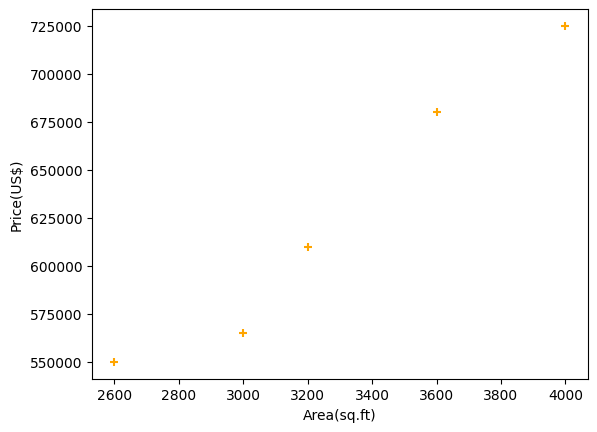

In [9]:
plt.xlabel("Area(sq.ft)")
plt.ylabel("Price(US$)")
plt.scatter(df.area,df.price,color="orange",marker="+")


In [10]:
reg = linear_model.LinearRegression()
reg.fit(df[["area"]],df.price)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
reg.predict(pd.DataFrame([[3300]], columns=["area"]))

array([628715.75342466])

In [22]:
reg.coef_


array([135.78767123])

In [21]:
reg.intercept_

np.float64(180616.43835616432)

we have y = mx +b 
so y is price that you need to predict and m is coef_ and x is area and b is intercept 

In [23]:
135.78767123*3300 + 180616.43835616432

628715.7534151643

In [25]:
p = pd.read_csv("prediction.csv")
p.head()

,area
0,2000
1,2200
2,2400
3,2600
4,2800


In [29]:
prices = reg.predict(p[["area"]])
prices

array([452191.78082192, 479349.31506849, 506506.84931507, 533664.38356164,
       560821.91780822, 587979.45205479, 615136.98630137, 642294.52054795,
       669452.05479452, 696609.5890411 , 723767.12328767, 750924.65753425,
       791660.95890411, 859554.79452055])

In [31]:
p["prices"] = prices
p

,area,prices
0,2000,452191.780822
1,2200,479349.315068
2,2400,506506.849315
3,2600,533664.383562
4,2800,560821.917808
5,3000,587979.452055
6,3200,615136.986301
7,3400,642294.520548
8,3600,669452.054795
9,3800,696609.589041


In [32]:
p.to_csv("prediction.csv", index=False)

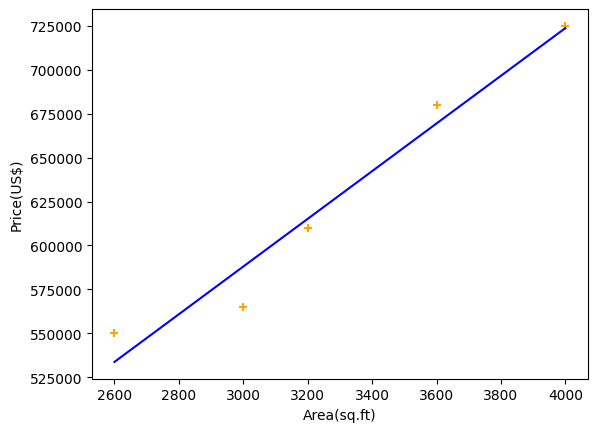

In [33]:
plt.xlabel("Area(sq.ft)")
plt.ylabel("Price(US$)")
plt.scatter(df.area,df.price,color="orange",marker="+")
plt.plot(df.area, reg.predict(df[["area"]]), color="blue")